# Análisis Exploratorio de Datos: Patrones de Venta en el Canal Autoservicio

**Categoría de mercado:** Productos de limpieza para el hogar (canal autoservicio, México)

**Rol:** Análisis exploratorio, diseño visual y visualización end-to-end (individual)

**Stack:** Python · pandas · NumPy · Matplotlib · Seaborn

## Contexto

Este proyecto continúa el [pipeline ETL de consolidación de datos de ventas](https://github.com/ReginaPema/etl-sales-data-cleaning). Parte del dataset limpio de 122,002 ventas semanales (2022–2023) para responder preguntas de negocio mediante análisis exploratorio de datos (EDA): distribución de ventas, concentración por marca y segmento, estacionalidad, relaciones entre variables, desempeño geográfico y detección de outliers.

## Nota metodológica importante

El dataset consolidado incluye, además de las seis áreas regionales de venta, una fila de **`Total Nacional`** que es la suma agregada de esas seis áreas. Si este análisis se hiciera sobre el dataset completo sin filtrar, cada estadística quedaría distorsionada por el doble conteo. Por eso, **todo este EDA trabaja únicamente sobre las filas de `Área Regional`** (101,012 de las 122,002 filas totales); el total nacional se usa solo como cifra de referencia cuando se menciona explícitamente.

## Sistema de diseño visual

Las diez visualizaciones de este notebook comparten una paleta y un estilo consistentes, pensados para que cada gráfica se lea como parte de un mismo producto analítico.

## Objetivo

1. Entender la distribución general de las ventas y detectar sesgos.
2. Identificar qué segmentos y marcas concentran el negocio.
3. Analizar la evolución temporal y la estacionalidad.
4. Explorar relaciones entre variables numéricas clave.
5. Comparar el desempeño entre las seis áreas de venta.
6. Detectar outliers y anomalías que requieran investigación adicional.

## Resultado

Diez visualizaciones y un conjunto de hallazgos accionables: el negocio está fuertemente concentrado en el segmento **Bleach** y la marca **Cloralex**, tiene un patrón estacional claro ligado a la temporada cálida, y su crecimiento es impulsado principalmente por volumen más que por precio.


---

# 1. Carga de datos y base de trabajo

Se carga el dataset consolidado en formato Parquet (conserva tipos `datetime` y `category`) y se
separan las filas de área regional —base de este análisis— del total nacional, que se conserva
aparte como referencia.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

df_completo = pd.read_parquet("df_consolidado_final.parquet")

# Base de trabajo: solo áreas regionales (excluye el consolidado nacional duplicado)
df = df_completo[df_completo['region_type'] == 'Área Regional'].copy()
nacional = df_completo[df_completo['region_type'] == 'Total Nacional'].copy()

print(f"Filas totales en el dataset: {len(df_completo):,}")
print(f"Filas de área regional (base EDA): {len(df):,}")
print(f"Filas de total nacional (excluidas de aquí en adelante): {len(nacional):,}")
print(f"\nPeriodo de ventas: {df['date'].min().strftime('%Y-%m-%d')} a {df['date'].max().strftime('%Y-%m-%d')}")
print(f"Ventas totales (áreas regionales): ${df['total_value_sales'].sum():,.2f}")
print(f"Nulos: {df.isnull().sum().sum()}")

Filas totales en el dataset: 122,002
Filas de área regional (base EDA): 101,012
Filas de total nacional (excluidas de aquí en adelante): 20,990

Periodo de ventas: 2022-01-09 a 2023-07-17
Ventas totales (áreas regionales): $5,521,430.57
Nulos: 0


### Sistema de diseño: paleta y estilo

Una paleta semántica (colores con un rol fijo: principal, secundario, acento, neutro...) en vez de colores genéricos de matplotlib, y dos mapas de color continuos, uno divergente y uno secuencial, que evitan el clásico rojo-verde (daltonismo). Los mismos colores se asignan de forma **consistente** a cada segmento y región a lo largo de todo el notebook, para que un color siempre signifique lo mismo.

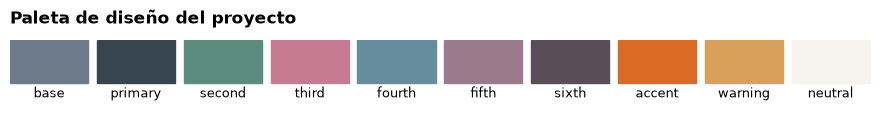

In [150]:
PALETTE = {
    "base":       "#6C7A89",  # gris azulado
    "primary":    "#36454F",  # azul charcoal
    "second":     "#5B8C7E",  # verde
    "third":      "#C77B93",  # rosa
    "fourth":     "#658D9D",  # muted blue
    "fifth":      "#9A7B8B",  # muted pink
    "sixth":      "#594D58",  # graphite red
    "accent":     "#D96B27",  # coral      
    "warning":    "#D9A05B",  # mostaza     
    "neutral":    "#F7F3EE",  # beige claro
}

# Lista ordenada para gráficas categóricas
QUALITATIVE = [PALETTE["primary"], PALETTE["fifth"], PALETTE["second"],
               PALETTE["base"], PALETTE["fourth"], PALETTE["sixth"], PALETTE["warning"]]

# Colores fijos por segmento
SEGMENT_COLORS = dict(zip(
    df.groupby('segment', observed=True)['total_value_sales'].sum().sort_values(ascending=False).index,
    QUALITATIVE
))

# Colores fijos por región
REGION_COLORS = dict(zip(sorted(df['region_short'].unique()), QUALITATIVE))

# Mapas de color continuos
CMAP_DIVERGING = LinearSegmentedColormap.from_list("diverging_custom", [PALETTE["third"], PALETTE["neutral"], PALETTE["second"]])
CMAP_SEQUENTIAL = LinearSegmentedColormap.from_list("sequential_custom", [PALETTE["neutral"], PALETTE["primary"]])

def aplicar_estilo():
    """Aplica el estilo visual consistente a toda gráfica de matplotlib/seaborn del notebook"""
    plt.rcParams.update({
        'figure.facecolor': 'white', 'axes.facecolor': 'white',
        'axes.spines.top': False, 'axes.spines.right': False,
        'axes.edgecolor': '#888888', 'axes.linewidth': 0.8,
        'axes.grid': True, 'grid.color': '#D9D9D9', 'grid.linewidth': 0.6, 'grid.alpha': 0.6,
        'axes.axisbelow': True,
        'font.family': 'DejaVu Sans', 'font.size': 10.5,
        'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
        'axes.labelsize': 10, 'axes.labelweight': 'medium',
        'legend.frameon': False, 'legend.fontsize': 9.5,
        'xtick.color': '#333333', 'ytick.color': '#333333',
        'figure.titlesize': 15, 'figure.titleweight': 'bold',
        'figure.figsize': (12, 6),
    })

aplicar_estilo()

fig, ax = plt.subplots(figsize=(9, 1.3))
for i, (nombre, color) in enumerate(PALETTE.items()):
    ax.add_patch(plt.Rectangle((i, 0), 0.9, 1, color=color))
    ax.text(i + 0.45, -0.35, nombre, ha='center', fontsize=9)
ax.set_xlim(0, len(PALETTE)); ax.set_ylim(-0.6, 1)
ax.axis('off')
plt.title('Paleta de diseño del proyecto', loc='left', fontsize=12)
plt.tight_layout()
plt.savefig("00_paleta_diseno.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Variables clave para el análisis

Se agrupan las columnas relevantes por tipo de pregunta de negocio que ayudan a responder: ventas, tiempo, geografía, producto, métricas de desempeño e indicadores binarios.

In [137]:
variables_clave = {
    'Ventas': ['total_value_sales', 'total_unit_sales', 'avg_weekly_price'],
    'Temporal': ['date', 'year', 'month', 'quarter', 'month_name', 'year_month'],
    'Geográfica': ['region_short', 'region_type'],
    'Producto': ['segment', 'brand', 'manufacturer', 'format', 'size'],
    'Desempeño': ['var_weekly_avg', 'var_pct', 'above_avg'],
    'Indicadores': ['high_value', 'high_turnover', 'vip_sale', 'star_product'],
}
for categoria, cols in variables_clave.items():
    disponibles = [c for c in cols if c in df.columns]
    print(f"{categoria:11} → {disponibles}")

Ventas      → ['total_value_sales', 'total_unit_sales', 'avg_weekly_price']
Temporal    → ['date', 'year', 'month', 'quarter', 'month_name', 'year_month']
Geográfica  → ['region_short', 'region_type']
Producto    → ['segment', 'brand', 'manufacturer', 'format', 'size']
Desempeño   → ['var_weekly_avg', 'var_pct', 'above_avg']
Indicadores → ['high_value', 'high_turnover', 'vip_sale', 'star_product']


# 3. Distribución de las ventas

## 3.1 Distribución general

Histogramas de valor y unidades vendidas (en escala logarítmica, por el fuerte sesgo), y boxplots de ventas por formato y segmento de producto.

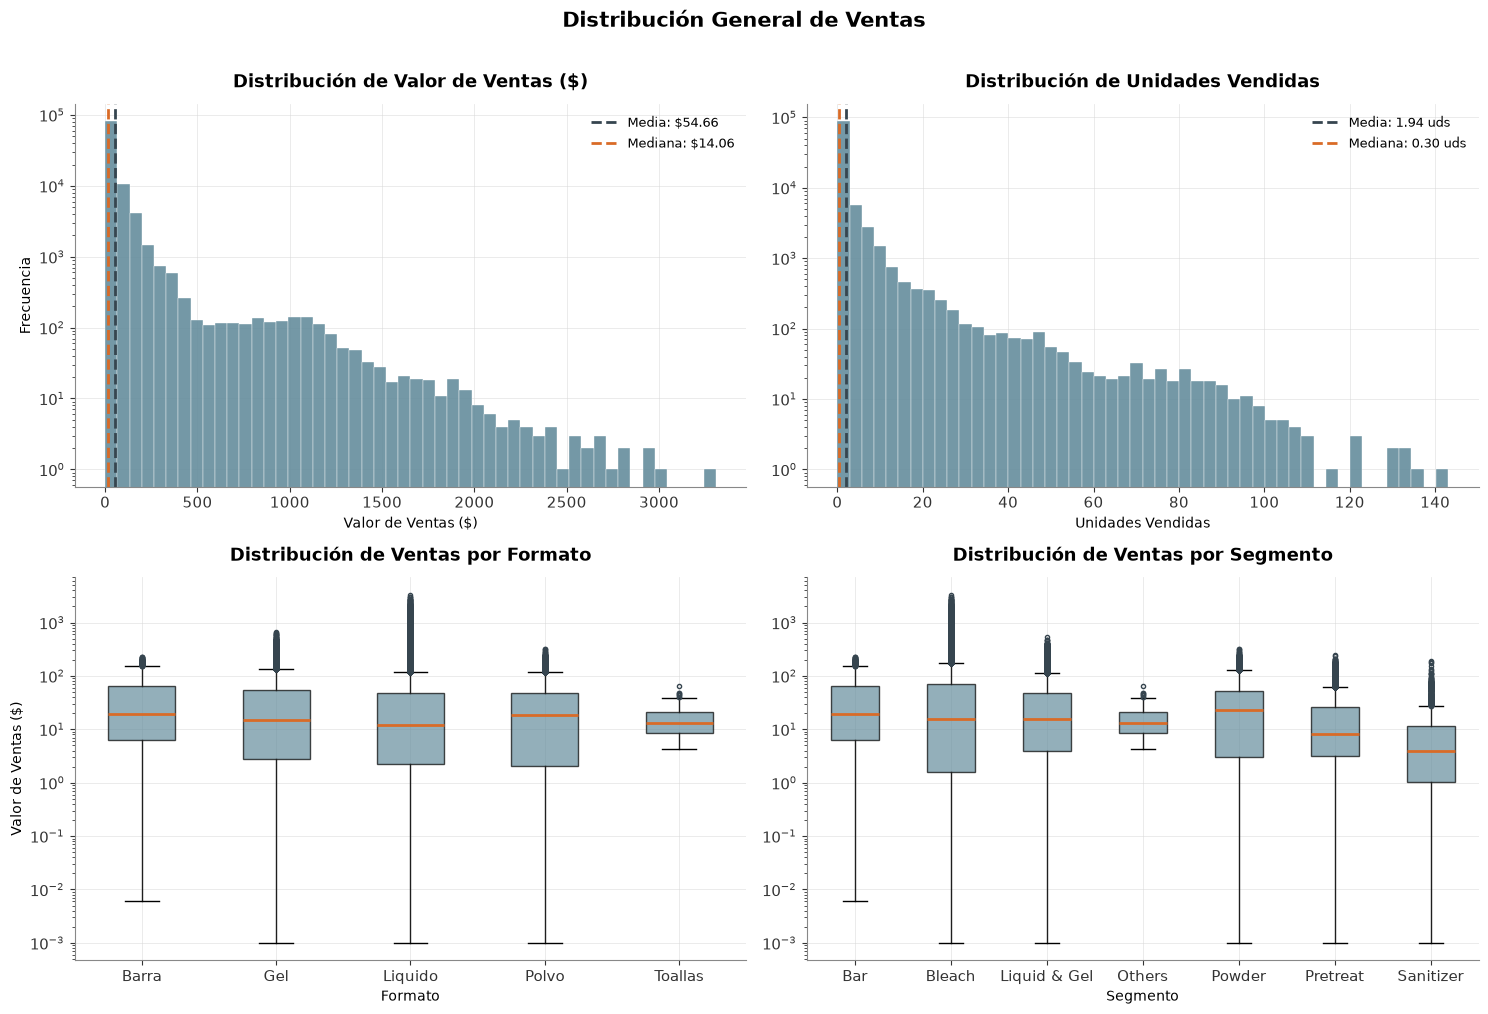

Ventas: Media $54.66 vs Mediana $14.06 → la media es 3.9x la mediana


In [138]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
graph_color=PALETTE['fourth']

# HISTOGRAMA 1: Total Value Sales
axes[0, 0].hist(df['total_value_sales'], bins=50, color=graph_color, edgecolor='white', linewidth=0.3, alpha=0.9)
media, mediana = df['total_value_sales'].mean(), df['total_value_sales'].median()
axes[0, 0].axvline(media, color=PALETTE['primary'], linestyle='--', linewidth=2, label=f'Media: ${media:.2f}')
axes[0, 0].axvline(mediana, color=PALETTE['accent'], linestyle='--', linewidth=2, label=f'Mediana: ${mediana:.2f}')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Distribución de Valor de Ventas ($)')
axes[0, 0].set_xlabel('Valor de Ventas ($)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()

# HISTOGRAMA 2: Total Unit Sales
axes[0, 1].hist(df['total_unit_sales'], bins=50, color=graph_color, edgecolor='white', linewidth=0.3, alpha=0.9)
axes[0, 1].axvline(df['total_unit_sales'].mean(), color=PALETTE['primary'], linestyle='--', linewidth=2,
                    label=f"Media: {df['total_unit_sales'].mean():.2f} uds")
axes[0, 1].axvline(df['total_unit_sales'].median(), color=PALETTE['accent'], linestyle='--', linewidth=2,
                    label=f"Mediana: {df['total_unit_sales'].median():.2f} uds")
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Distribución de Unidades Vendidas')
axes[0, 1].set_xlabel('Unidades Vendidas')
axes[0, 1].legend()

# BOXPLOT 1: Ventas por Formato
box_kwargs_1 = dict(patch_artist=True, boxprops=dict(facecolor=graph_color, alpha=0.7),
                     medianprops=dict(color=PALETTE['accent'], linewidth=2),
                     flierprops=dict(markeredgecolor=PALETTE['primary'], markersize=3))
df.boxplot(column='total_value_sales', by='format', ax=axes[1, 0], **box_kwargs_1)
plt.sca(axes[1, 0]); plt.title('')
axes[1, 0].set_title('Distribución de Ventas por Formato')
axes[1, 0].set_xlabel('Formato'); axes[1, 0].set_ylabel('Valor de Ventas ($)')
axes[1, 0].set_yscale('log')

# BOXPLOT 2: Ventas por Segmento
box_kwargs_2 = dict(patch_artist=True, boxprops=dict(facecolor=graph_color, alpha=0.7),
                     medianprops=dict(color=PALETTE['accent'], linewidth=2),
                     flierprops=dict(markeredgecolor=PALETTE['primary'], markersize=3))
df.boxplot(column='total_value_sales', by='segment', ax=axes[1, 1], **box_kwargs_2)
plt.sca(axes[1, 1]); plt.title('')
axes[1, 1].set_title('Distribución de Ventas por Segmento')
axes[1, 1].set_xlabel('Segmento')
axes[1, 1].set_yscale('log')

fig.suptitle('Distribución General de Ventas', y=1.01)
plt.tight_layout()
plt.savefig('01_distribucion_ventas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Ventas: Media ${media:.2f} vs Mediana ${mediana:.2f} → la media es {media/mediana:.1f}x la mediana")

### Hallazgos:

- La distribución de valor de venta tiene un sesgo positivo extremo: la media (\$54.66) es **~3.9 veces** la mediana (\$14.06). La mayoría de las transacciones son de bajo valor, con una cola de transacciones grandes que arrastra el promedio hacia arriba.
- El mismo patrón se repite en unidades vendidas donde la mediana de 0.30 unidades, o sea, más de la mitad de los registros venden menos de 1 unidad esa semana.
- Por formato, **Polvo**, **Líquido** y **Gel** muestran las medianas y outliers más altos; **Barra** y **Toallas** tienen rangos más compactos y predecibles.
- Por segmento, **Bleach** y **Liquid & Gel** son los que más dispersión y outliers de mayor valor presentan (consistente con ser los segmentos que más adelante resultan dominantes en ventas).

**Interpretación:** el negocio opera bajo un modelo de alto volumen y ticket bajo, con una minoría de transacciones (probablemente compras mayoristas o de puntos de venta grandes) que generan una parte desproporcionada del ingreso.

## 3.2 Ventas por segmento

Participación de cada segmento de producto en las ventas totales.

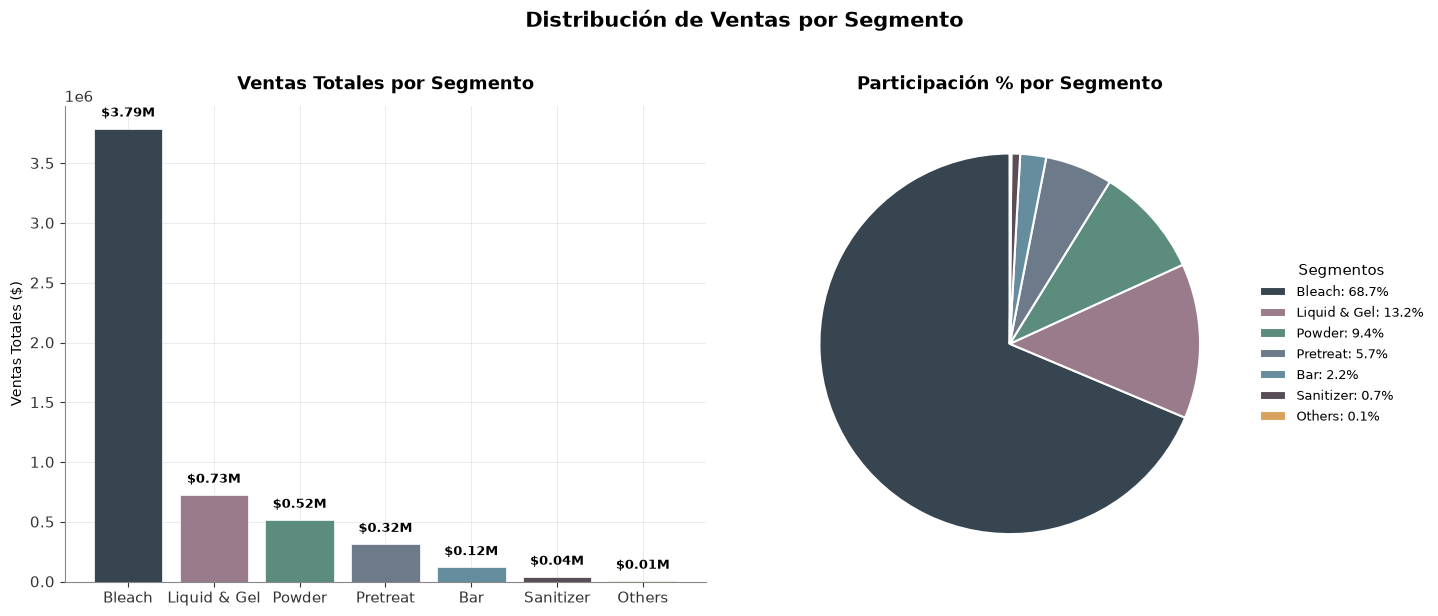

                     sum  count   mean  percentage
segment                                           
Bleach        3790642.19  43489  87.16       68.65
Liquid & Gel   727028.13  18997  38.27       13.17
Powder         517510.89  14779  35.02        9.37
Pretreat       316001.12  15985  19.77        5.72
Bar            121769.67   3019  40.33        2.21
Sanitizer       40957.87   4263   9.61        0.74
Others           7520.71    480  15.67        0.14


In [139]:
ventas_segmento = df.groupby('segment', observed=True)['total_value_sales'].agg(['sum', 'count', 'mean']).sort_values('sum', ascending=False)
ventas_segmento['percentage'] = (ventas_segmento['sum'] / ventas_segmento['sum'].sum()) * 100
colores_segmento = [SEGMENT_COLORS[s] for s in ventas_segmento.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Distribución de Ventas por Segmento', y=1.02)

# BARRA VERTICALES: Ventas Totales por Segmento
axes[0].bar(range(len(ventas_segmento)), ventas_segmento['sum'], color=colores_segmento, edgecolor='white', linewidth=0.5)
axes[0].set_xticks(range(len(ventas_segmento)))
axes[0].set_xticklabels(ventas_segmento.index)
axes[0].set_title('Ventas Totales por Segmento')
axes[0].set_ylabel('Ventas Totales ($)')
for i, v in enumerate(ventas_segmento['sum']):
    axes[0].text(i, v + ventas_segmento['sum'].max()*0.02, f'${v/1e6:.2f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

# PIE: Participación porcentual por Segmento
axes[1].pie(ventas_segmento['sum'], colors=colores_segmento, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Participación % por Segmento')
legend_labels = [f'{seg}: {pct:.1f}%' for seg, pct in zip(ventas_segmento.index, ventas_segmento['percentage'])]
axes[1].legend(legend_labels, title="Segmentos", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.savefig('02_ventas_por_segmento.png', dpi=150, bbox_inches='tight')
plt.show()

print(ventas_segmento.round(2))

### Hallazgos:

- **Bleach domina con \$3.79M (68.7% del total)**, más de dos tercios de cada dólar vendido proviene de este segmento.
- **Liquid & Gel** es un lejano segundo lugar (\$0.73M, 13.2%), y **Powder** el tercero (\$0.52M, 9.4%). 
- Los tres primeros concentran **91.2%** de las ventas.
- Los cuatro segmentos restantes (Pretreat, Bar, Sanitizer, Others) combinados apenas suman 8.8%.

**Interpretación:** existe una dependencia crítica de un solo segmento. Bleach por sí solo supera la regla de Pareto (80/20). Cualquier caída en su demanda impactaría de forma desproporcionada los ingresos totales del negocio, lo que sugiere una oportunidad de diversificación hacia Liquid & Gel y Powder.

## 3.3 Ventas por marca

Top 10 marcas por valor de venta acumulado.

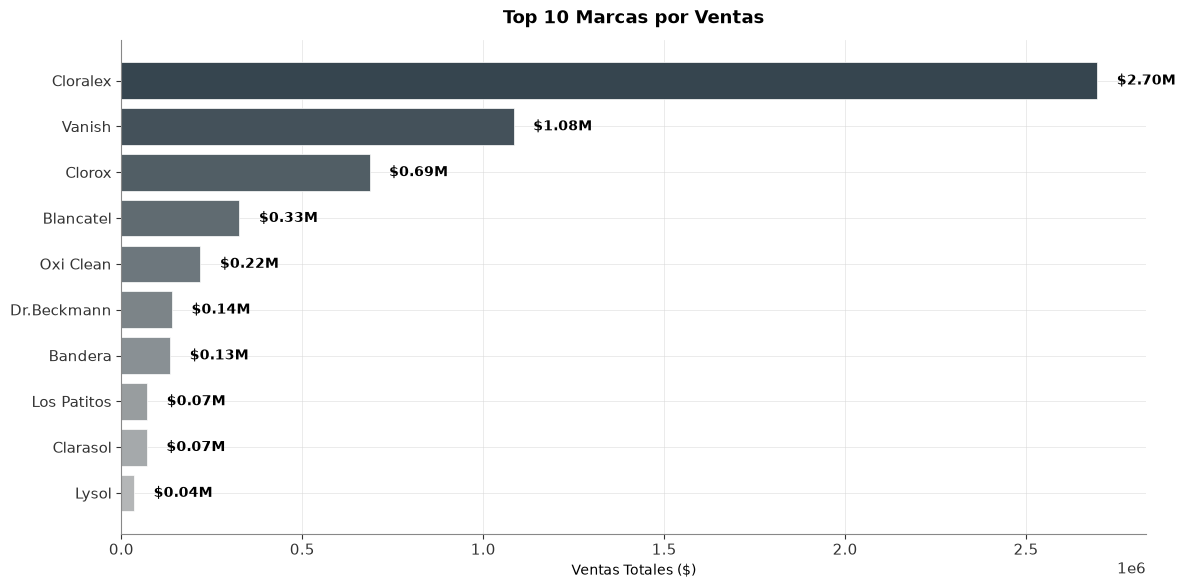

 1. Cloralex      $2,696,809.34 (48.8%)
 2. Vanish        $1,084,144.86 (19.6%)
 3. Clorox        $  685,875.94 (12.4%)
 4. Blancatel     $  326,242.02 (5.9%)
 5. Oxi Clean     $  218,485.40 (4.0%)
 6. Dr.Beckmann   $  139,859.65 (2.5%)
 7. Bandera       $  134,968.52 (2.4%)
 8. Los Patitos   $   71,372.85 (1.3%)
 9. Clarasol      $   70,506.10 (1.3%)
10. Lysol         $   35,278.68 (0.6%)


In [140]:
ventas_marca = df.groupby('brand', observed=True)['total_value_sales'].sum().sort_values(ascending=False).head(10)
colores_marca = [CMAP_SEQUENTIAL(0.35 + 0.65 * (1 - i / (len(ventas_marca) - 1))) for i in range(len(ventas_marca))]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(ventas_marca)), ventas_marca.values, color=colores_marca, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(ventas_marca)))
ax.set_yticklabels(ventas_marca.index)
ax.invert_yaxis()
ax.set_title('Top 10 Marcas por Ventas')
ax.set_xlabel('Ventas Totales ($)')
for i, v in enumerate(ventas_marca.values):
    ax.text(v + ventas_marca.max()*0.02, i, f'${v/1e6:.2f}M', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('03_ventas_por_marca.png', dpi=150, bbox_inches='tight')
plt.show()

for i, (marca, ventas) in enumerate(ventas_marca.items(), 1):
    pct = (ventas / df['total_value_sales'].sum()) * 100
    print(f"{i:2}. {marca:13} ${ventas:>12,.2f} ({pct:.1f}%)")

### Hallazgos:

- **Cloralex domina con \$2.70M (48.8% del total)**, casi 1 de cada 2 dólares vendidos, y vende **2.5 veces más** que la segunda marca (Vanish, 19.6%).
- El top 3 (Cloralex + Vanish + Clorox) concentra **80.8%** de las ventas.
- Las últimas cinco marcas del top 10 (Dr.Beckmann, Bandera, Los Patitos, Clarasol, Lysol) combinadas apenas suman ~8%.

**Interpretación:** el mercado está tan concentrado en marca como en segmento, no es casualidad que Cloralex sea también líder de Bleach. Clorox, su competidor directo, tiene solo una cuarta parte de su cuota, lo que sugiere una posición de marca muy fuerte de Cloralex en el canal autoservicio.

# 4. Tendencia de ventas en el tiempo

## 4.1 Evolución mensual

C:\Users\letit\AppData\Local\Temp\ipykernel_9672\1709450014.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([t.get_text()[2:] for t in ax.get_xticklabels()])
C:\Users\letit\AppData\Local\Temp\ipykernel_9672\1709450014.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([t.get_text()[2:] for t in ax.get_xticklabels()])


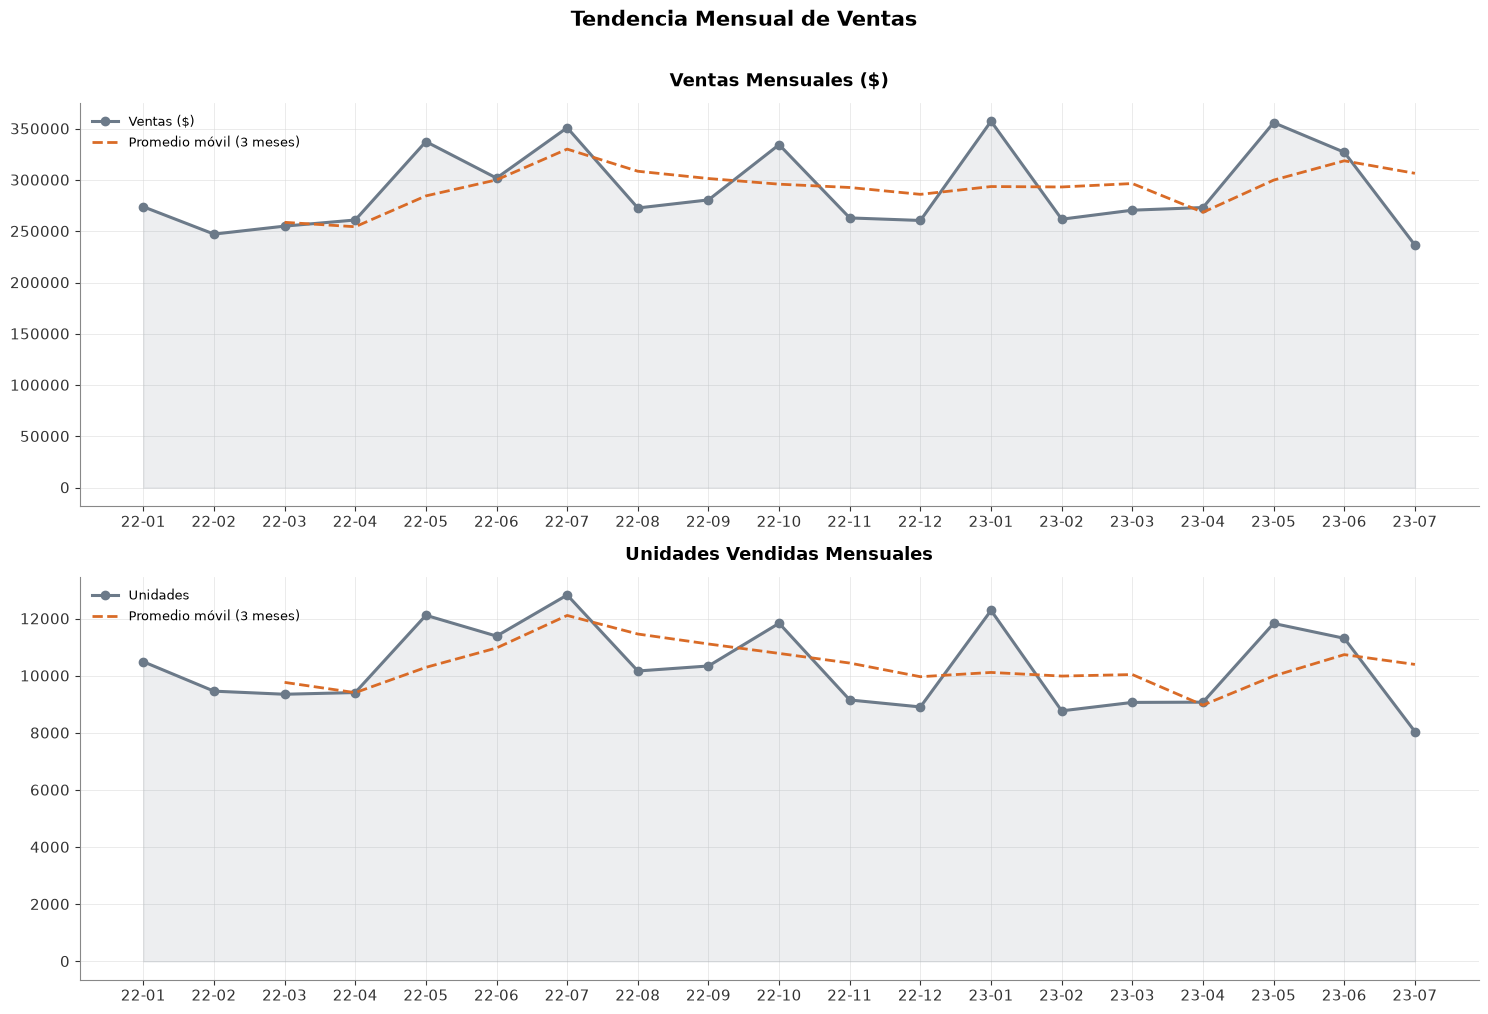

Mes pico: 2023-01 ($357,314)
Mes valle (excl. 2023-07 incompleto): 2022-02 ($247,268)


In [141]:
ventas_mensuales = df.groupby('year_month').agg(total_value_sales=('total_value_sales', 'sum'),
                                                  total_unit_sales=('total_unit_sales', 'sum')).sort_index()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('Tendencia Mensual de Ventas', y=1.01)
line_color=PALETTE['base']

# DIAGRAMA LINEAL 1: Ventas Mensuales ($)
axes[0].plot(ventas_mensuales.index, ventas_mensuales['total_value_sales'], marker='o', linewidth=2.2, color=line_color, label='Ventas ($)')
axes[0].fill_between(ventas_mensuales.index, ventas_mensuales['total_value_sales'], alpha=0.12, color=line_color)
if len(ventas_mensuales) >= 3:
    ma_3 = ventas_mensuales['total_value_sales'].rolling(window=3).mean()
    axes[0].plot(ma_3.index, ma_3.values, '--', linewidth=2, color=PALETTE['accent'], label='Promedio móvil (3 meses)')
axes[0].set_title('Ventas Mensuales ($)')
axes[0].legend(); axes[0].tick_params(axis='x')

# DIAGRAMA LINEAL 2: Unidades Mensuales Vendidas
axes[1].plot(ventas_mensuales.index, ventas_mensuales['total_unit_sales'], marker='o', linewidth=2.2, color=line_color, label='Unidades')
axes[1].fill_between(ventas_mensuales.index, ventas_mensuales['total_unit_sales'], alpha=0.12, color=line_color)
if len(ventas_mensuales) >= 3:
    ma_3u = ventas_mensuales['total_unit_sales'].rolling(window=3).mean()
    axes[1].plot(ma_3u.index, ma_3u.values, '--', linewidth=2, color=PALETTE['accent'], label='Promedio móvil (3 meses)')
axes[1].set_title('Unidades Vendidas Mensuales')
axes[1].legend(); axes[1].tick_params(axis='x')

for ax in axes:
    ax.set_xticklabels([t.get_text()[2:] for t in ax.get_xticklabels()])

plt.tight_layout()
plt.savefig('04_tendencia_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

vmen_completos = ventas_mensuales['total_value_sales'][ventas_mensuales.index != '2023-07']
print(f"Mes pico: {ventas_mensuales['total_value_sales'].idxmax()} (${ventas_mensuales['total_value_sales'].max():,.0f})")
print(f"Mes valle (excl. 2023-07 incompleto): {vmen_completos.idxmin()} (${vmen_completos.min():,.0f})")

### Hallazgos:

- Las ventas mensuales oscilan entre ~\$247K (valle) y ~\$357K (pico), un rango de ~44%.
- **Mayo** aparece consistentemente como mes fuerte en ambos años (2022 y 2023), junto con **enero** y **julio**, con julio 2023 truncado (datos solo hasta el día 17, por eso su caída aparente no es una tendencia real).
- **Febrero** es el mes más débil en ambos años, patrón consistente de "cuesta de enero" que se extiende a febrero.
- El promedio móvil de 3 meses muestra una tendencia relativamente estable, sin una caída ni un crecimiento sostenido pronunciado en el periodo.

**Interpretación:** existe estacionalidad, la demanda repunta en meses de mayor temperatura / limpieza de primavera (mayo) y se debilita después de la temporada navideña (febrero). Julio 2023 debe excluirse de cualquier proyección o comparación interanual por estar incompleto (datos solo hasta el día 17). Enero de 2022 sí cuenta con sus 4 semanas completas, igual que la mayoría de los meses del periodo, aunque la serie de datos comience el 9 de enero.

## 4.2 Ventas por trimestre

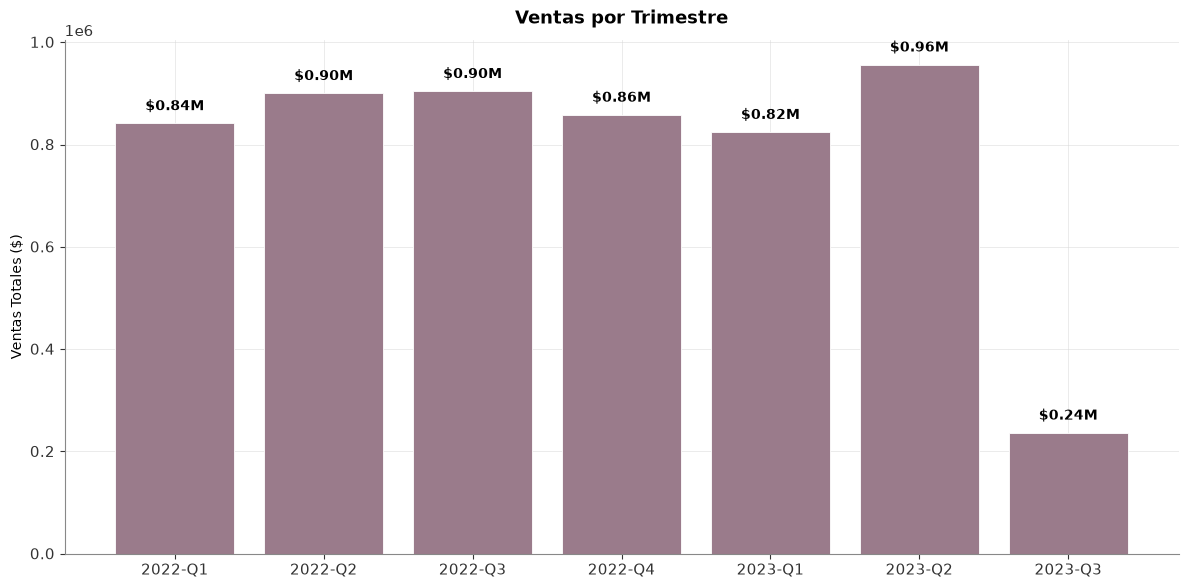

2022-Q1: $841,514
2022-Q2: $900,377
2022-Q3: $904,365
2022-Q4: $858,054
2023-Q1: $824,371
2023-Q2: $956,186
2023-Q3: $236,563


In [142]:
ventas_trimestre = df.groupby('year_quarter')['total_value_sales'].sum().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(ventas_trimestre)), ventas_trimestre.values, color=PALETTE['fifth'], edgecolor='white', linewidth=0.6)
ax.set_xticks(range(len(ventas_trimestre)))
ax.set_xticklabels(ventas_trimestre.index)
ax.set_title('Ventas por Trimestre')
ax.set_ylabel('Ventas Totales ($)')
for i, v in enumerate(ventas_trimestre.values):
    ax.text(i, v + ventas_trimestre.max()*0.02, f'${v/1e6:.2f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('05_ventas_trimestre.png', dpi=150, bbox_inches='tight')
plt.show()

for t, v in ventas_trimestre.items():
    print(f"{t}: ${v:,.0f}")

### Hallazgos:

- **2023-Q2** es el trimestre más fuerte del periodo completo (\$956K).
- **2023-Q3** aparece con el valor más bajo, pero es un trimestre incompleto (solo julio) y no representa una caída real.
- Entre trimestres completos, el rango va de \$824K (2023-Q1) a \$956K (2023-Q2), una variación de ~16%.
- Comparación interanual de trimestres equivalentes: Q1 cae ligeramente de 2022 a 2023 (\$841.5K → \$824.4K, -2.0%), mientras Q2 crece (\$900.4K → \$956.2K, +6.2%).

**Interpretación:** el negocio es relativamente estable a nivel trimestral, con Q2 como su temporada más fuerte de forma consistente. El crecimiento interanual es modesto pero positivo en el trimestre de mayor peso, lo que sugiere un negocio maduro en fase de mantenimiento más que de expansión acelerada.

## 4.3 Evolución mensual por segmento

C:\Users\letit\AppData\Local\Temp\ipykernel_9672\3900320736.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([t.get_text()[2:] for t in ax.get_xticklabels()])
C:\Users\letit\AppData\Local\Temp\ipykernel_9672\3900320736.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([t.get_text()[2:] for t in ax.get_xticklabels()])


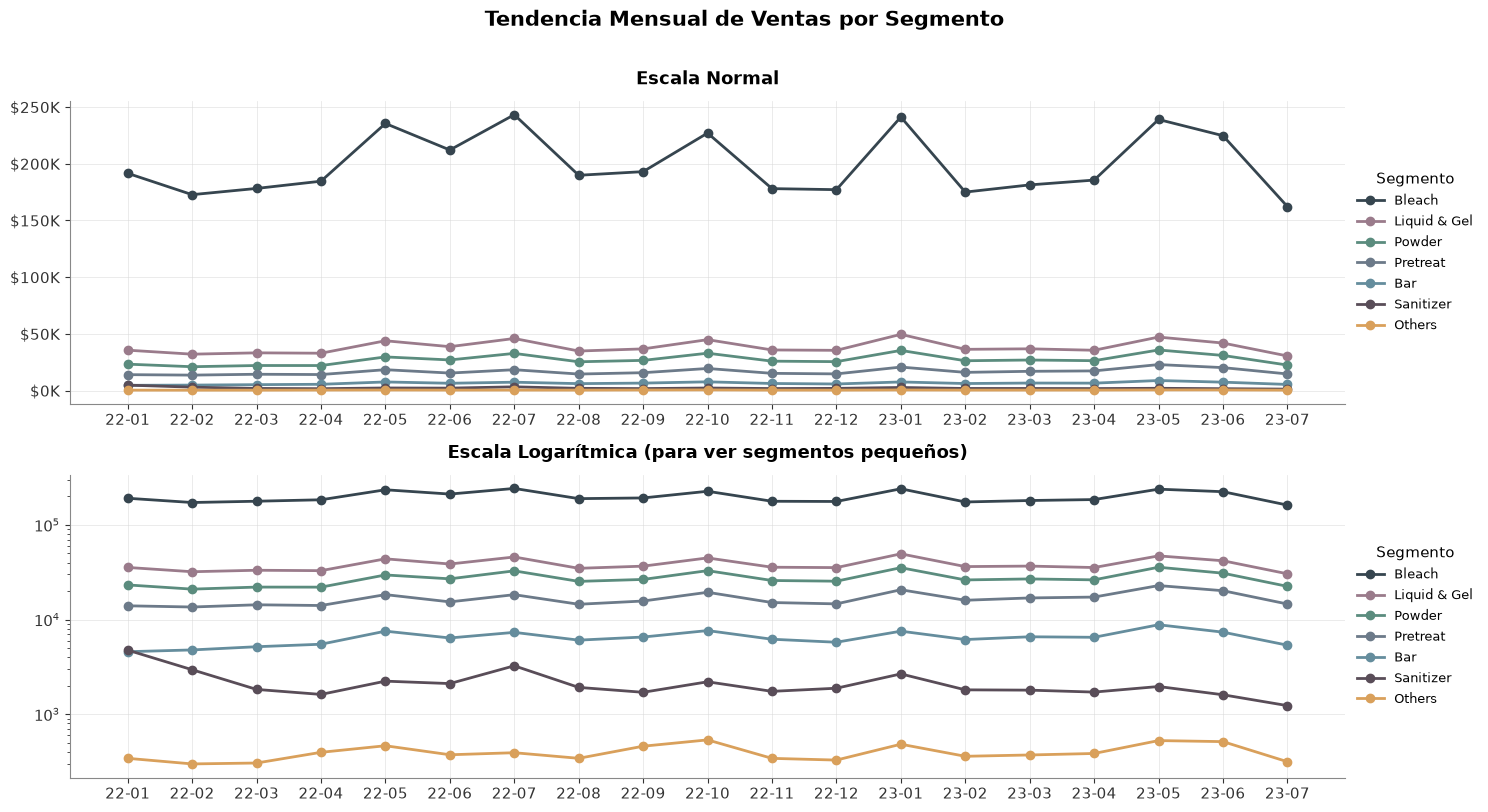

Segmento       Promedio/Mes   Mes Pico  Valor Pico   Mes Valle  Valor Valle
Bleach        $    201,583    2022-07 $  243,153     2022-02 $  172,657
Liquid & Gel  $     38,698    2023-01 $   49,518     2022-02 $   32,036
Powder        $     27,504    2023-05 $   35,736     2022-02 $   20,976
Pretreat      $     16,745    2023-05 $   22,870     2022-02 $   13,574
Bar           $      6,467    2023-05 $    8,814     2022-01 $    4,575
Sanitizer     $      2,207    2022-01 $    4,753     2023-06 $    1,604
Others        $        400    2022-10 $      535     2022-02 $      298


In [143]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
fig.suptitle('Tendencia Mensual de Ventas por Segmento', y=1.01)

resumen_segmentos = {}
for segmento in ventas_segmento.index:  # ya ordenados de mayor a menor venta
    ventas_seg = df[df['segment'] == segmento].groupby('year_month')['total_value_sales'].sum()
    if len(ventas_seg) == 0:
        continue
    color = SEGMENT_COLORS[segmento]
    axes[0].plot(ventas_seg.index, ventas_seg.values, marker='o', label=segmento, linewidth=2, color=color)
    axes[1].plot(ventas_seg.index, ventas_seg.values, marker='o', label=segmento, linewidth=2, color=color)

    ventas_seg_completos = ventas_seg[ventas_seg.index != '2023-07']
    resumen_segmentos[segmento] = {
        'total': ventas_seg_completos.sum(), 'promedio': ventas_seg_completos.mean(),
        'maximo': ventas_seg_completos.max(), 'minimo': ventas_seg_completos.min(),
        'mes_pico': ventas_seg_completos.idxmax(), 'mes_valle': ventas_seg_completos.idxmin(),
    }

axes[0].set_title('Escala Normal')
axes[0].legend(title='Segmento', loc='center left', bbox_to_anchor=(1, 0.5))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e3:.0f}K'))

axes[1].set_yscale('log')
axes[1].set_title('Escala Logarítmica (para ver segmentos pequeños)')
axes[1].legend(title='Segmento', loc='center left', bbox_to_anchor=(1, 0.5))

# Acortar las etiquetas del eje x: '2022-01' → '22-01'
for ax in axes:
    ax.set_xticklabels([t.get_text()[2:] for t in ax.get_xticklabels()])

plt.tight_layout()
plt.savefig('06_tendencia_por_segmento.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'Segmento':<13} {'Promedio/Mes':>13} {'Mes Pico':>10} {'Valor Pico':>11} {'Mes Valle':>11} {'Valor Valle':>12}")
for seg, d in resumen_segmentos.items():
    print(f"{seg:<13} ${d['promedio']:>11,.0f} {d['mes_pico']:>10} ${d['maximo']:>9,.0f} {d['mes_valle']:>11} ${d['minimo']:>9,.0f}")

### Hallazgos:

- **Bleach** se mantiene por encima de todos los demás segmentos en todos los meses del periodo, siguiendo el mismo patrón estacional general (pico en mayo, valle en febrero).
- Los segmentos medianos (Liquid & Gel, Powder) muestran variaciones mensuales visibles pero mucho menores en magnitud absoluta.
- Sanitizer y Others son casi planos en la escala normal, solo se distinguen en la vista logarítmica, y no siguen necesariamente el mismo patrón estacional que Bleach.

**Interpretación:** la estacionalidad del negocio está impulsada casi en su totalidad por Bleach. Si se busca suavizar la dependencia estacional del negocio, los segmentos con comportamiento más plano (Sanitizer, Others) podrían ofrecer un flujo de ingresos más predecible durante todo el año, aunque su tamaño actual es marginal.

# 5. Relación entre variables

## 5.1 Matriz de correlación

Se usa el mapa de color divergente propio del proyecto (rosa–crema–verde).

**Nota:** `above_avg` se excluye de esta matriz porque es constante (siempre 0) dentro de cada área individual. Esto es un hallazgo en sí mismo: el 0% de las ventas por área supera su `total_unit_avg_weekly_sales`, pero en el consolidado nacional sí lo hace el 20.5% de las filas. Esto sugiere que ese promedio histórico fue calibrado a una escala más amplia (probablemente nacional), no a la de una sola área. Una variable constante no aporta información a una matriz de correlación y además queda indefinida (correlación NaN), por eso se deja fuera.

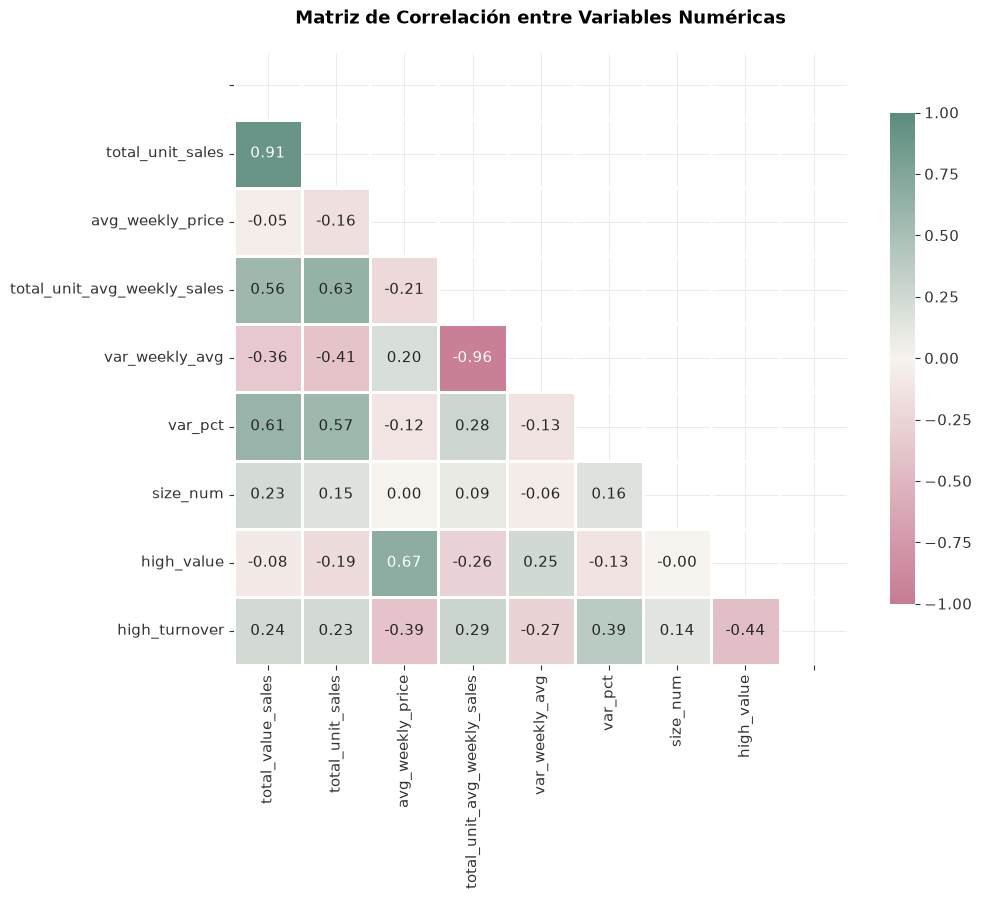

Correlaciones |r| > 0.4:
  total_value_sales <-> total_unit_sales: 0.907
  high_value <-> avg_weekly_price: 0.674
  total_unit_sales <-> total_unit_avg_weekly_sales: 0.631
  var_pct <-> total_value_sales: 0.606
  var_pct <-> total_unit_sales: 0.571
  total_value_sales <-> total_unit_avg_weekly_sales: 0.563
  total_unit_sales <-> var_weekly_avg: -0.405
  high_value <-> high_turnover: -0.436
  var_weekly_avg <-> total_unit_avg_weekly_sales: -0.965


In [144]:
vars_numericas = ['total_value_sales', 'total_unit_sales', 'avg_weekly_price', 'total_unit_avg_weekly_sales',
                   'var_weekly_avg', 'var_pct', 'size_num', 'high_value', 'high_turnover']
df_corr = df[vars_numericas].corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(df_corr, dtype=bool))
ax = sns.heatmap(df_corr, mask=mask, annot=True, fmt='.2f', cmap=CMAP_DIVERGING, square=True,
                  linewidths=1, linecolor='white', cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1, center=0)

# Ocultar la primera etiqueta del eje Y (total_value_sales) y la última del eje X (high_turnover),
# ya que esa fila y esa columna quedan completamente enmascaradas y no muestran ninguna celda
etiquetas_y = [t.get_text() for t in ax.get_yticklabels()]
etiquetas_y[0] = ''
ax.set_yticklabels(etiquetas_y)

etiquetas_x = [t.get_text() for t in ax.get_xticklabels()]
etiquetas_x[-1] = ''
ax.set_xticklabels(etiquetas_x)

plt.title('Matriz de Correlación entre Variables Numéricas', pad=20)
plt.tight_layout()
plt.savefig('07_matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

corr_pairs = df_corr.unstack()
corr_pairs = corr_pairs[abs(corr_pairs) > 0.4]
corr_pairs = corr_pairs[corr_pairs != 1.0].sort_values(ascending=False).drop_duplicates()
print("Correlaciones |r| > 0.4:")
for (v1, v2), r in corr_pairs.items():
    print(f"  {v1} <-> {v2}: {r:.3f}")

### Hallazgos

- **`total_value_sales` ↔ `total_unit_sales`: r = 0.91 (muy fuerte).** Vender más unidades se traduce casi linealmente en más ingresos, no hay grandes distorsiones por descuentos o mezcla de precios que rompan esa relación.
- **`high_value` ↔ `avg_weekly_price`: r = 0.67.** Confirma que la variable derivada `high_value` (creada en el ETL) está bien construida ya que efectivamente distingue productos de precio alto.
- **`total_unit_avg_weekly_sales` ↔ `var_weekly_avg`: r = -0.97 (fuerte negativa).** Los productos de mayor rotación histórica tienen menor variación semanal absoluta, o sea, son más predecibles; los de baja rotación son más erráticos.
- **`avg_weekly_price` no correlaciona con `total_value_sales`** (fuera del umbral de 0.4): productos caros y baratos generan niveles de venta similares en conjunto. El ingreso no depende del precio unitario sino del volumen.

**Interpretación:** el crecimiento del negocio está impulsado por volumen (unidades), no por precio. Esto es consistente con el patrón de "alto volumen, bajo ticket" identificado en la sección 3.

## 5.2 Relaciones bivariadas

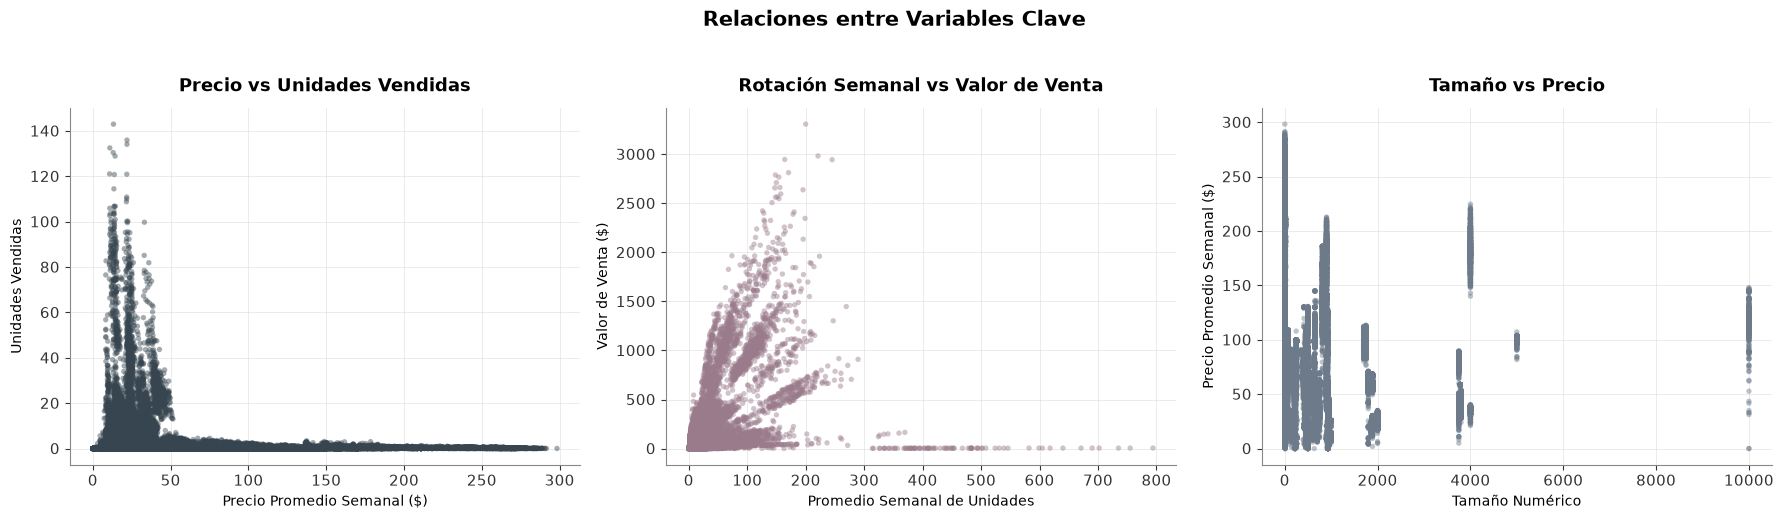

Correlación Precio-Unidades: -0.161
Correlación Tamaño-Precio: 0.003


In [145]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relaciones entre Variables Clave', y=1.03)

axes[0].scatter(df['avg_weekly_price'], df['total_unit_sales'], alpha=0.45, s=15, edgecolors='none', color=PALETTE['primary'])
axes[0].set_title('Precio vs Unidades Vendidas')
axes[0].set_xlabel('Precio Promedio Semanal ($)'); axes[0].set_ylabel('Unidades Vendidas')

axes[1].scatter(df['total_unit_avg_weekly_sales'], df['total_value_sales'], alpha=0.45, s=15, edgecolors='none', color=PALETTE['fifth'])
axes[1].set_title('Rotación Semanal vs Valor de Venta')
axes[1].set_xlabel('Promedio Semanal de Unidades'); axes[1].set_ylabel('Valor de Venta ($)')

axes[2].scatter(df['size_num'], df['avg_weekly_price'], alpha=0.45, s=15, edgecolors='none', color=PALETTE['base'])
axes[2].set_title('Tamaño vs Precio')
axes[2].set_xlabel('Tamaño Numérico'); axes[2].set_ylabel('Precio Promedio Semanal ($)')

plt.tight_layout()
plt.savefig('08_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Correlación Precio-Unidades: {df['avg_weekly_price'].corr(df['total_unit_sales']):.3f}")
print(f"Correlación Tamaño-Precio: {df['size_num'].corr(df['avg_weekly_price']):.3f}")

### Hallazgos:

- **Precio vs unidades:** forma de "L invertida". La masa de transacciones se concentra en precio bajo y pocas unidades; los productos con más de 100 unidades vendidas están casi exclusivamente en el rango de precio bajo (\$5–\$50). Ningún producto por encima de \$100 supera ~50 unidades.
- **Rotación semanal vs valor:** "forma de cono", relación positiva con dispersión creciente. A mayor rotación histórica, mayor y más variable es el valor de venta. Los outliers superiores (mayor valor a rotación moderada) son los candidatos a "producto estrella".
- **Tamaño vs precio:** sin relación lineal clara. Los tamaños se agrupan en columnas discretas (envases estandarizados: ~250ml, 500ml, 1L, 2L…), y para un mismo tamaño el rango de precio es amplio, lo que indica que el precio lo determina la marca y el segmento, no el tamaño.

*Nota: `avg_weekly_price` es el precio promedio de venta semanal (ASP): `total_value_sales` / `total_unit_sales`, ambos ya agregados por semana, no un precio de lista fijo por unidad.*

**Interpretación:** el "motor de ingresos" del negocio son productos de precio bajo-medio (\$10–50) con alto volumen. No hay evidencia de economía de escala por tamaño de envase. Una oportunidad potencial sería evaluar presentaciones de mayor tamaño con descuento por volumen.

# 6. Distribución geográfica de ventas

Comparación de desempeño entre las seis áreas de venta. El total nacional (`Total Nacional`) queda fuera de esta comparación por ser la suma de estas seis áreas, no una séptima región independiente. Compararlo junto a las áreas inflaría artificialmente su participación y llevaría a conclusiones erróneas sobre "la región con más ventas".

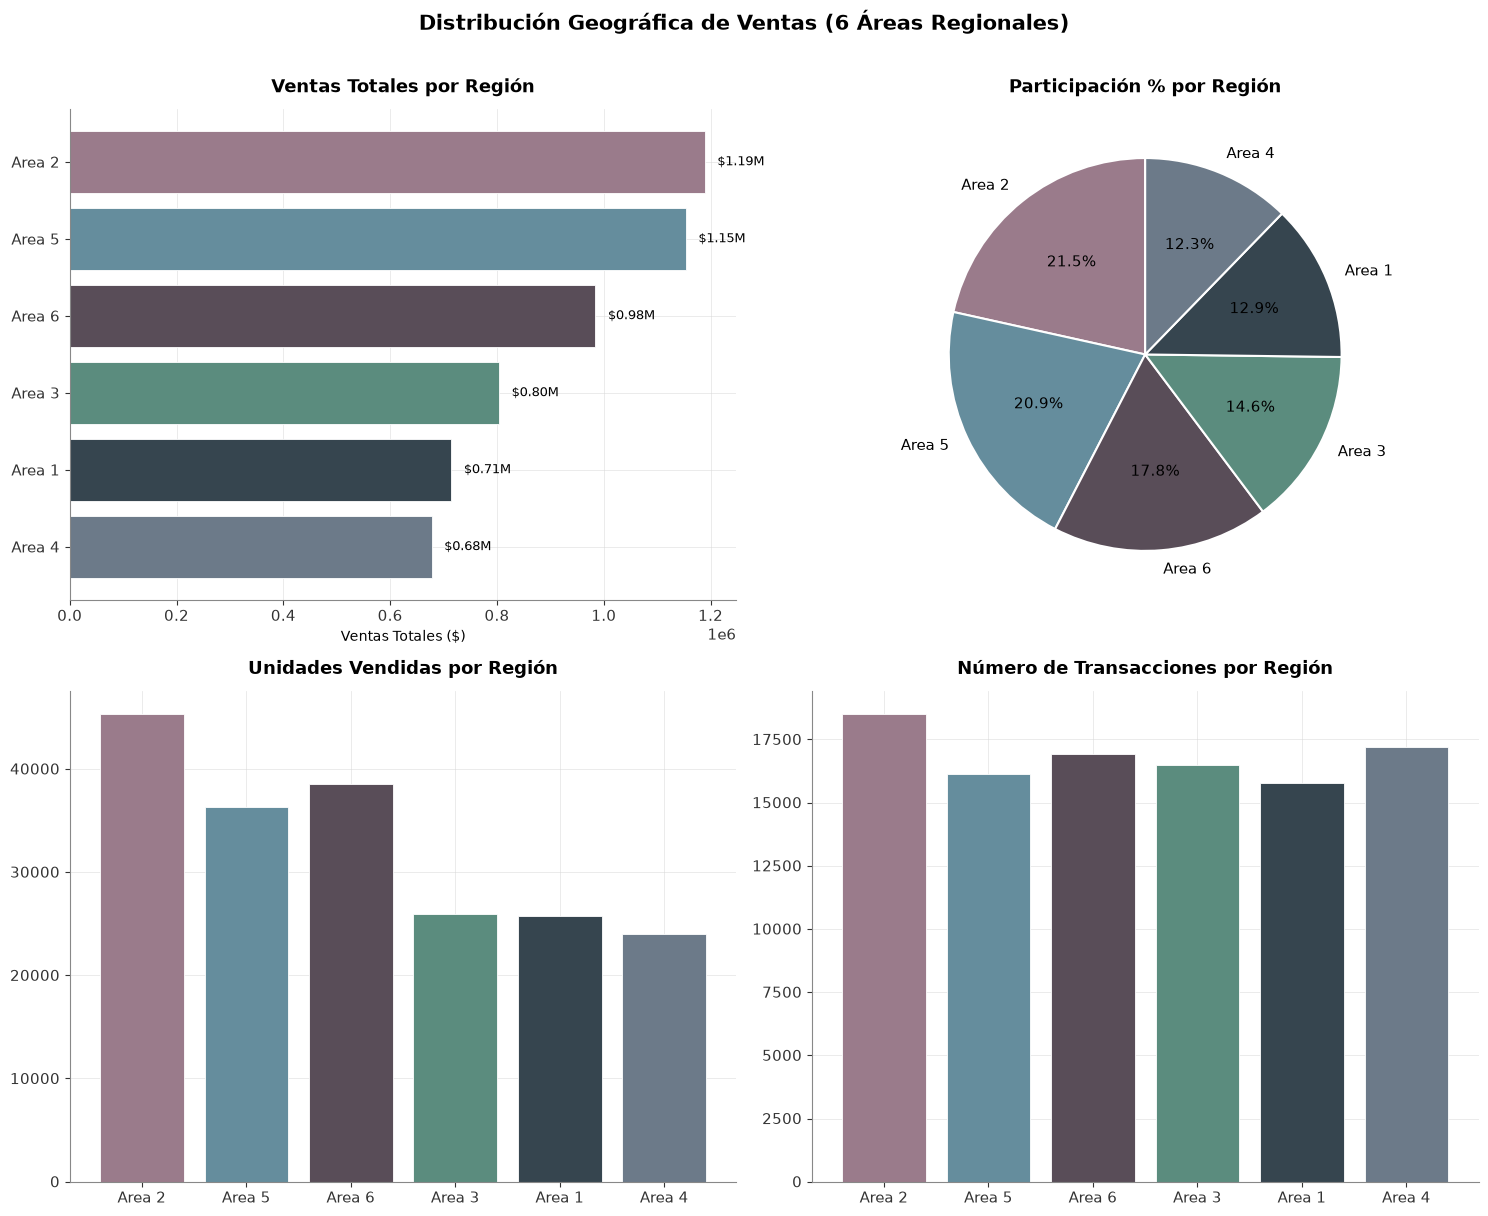

              total_value_sales  total_unit_sales  num_transactions  \
region_short                                                          
Area 2               1188796.15          45319.92             18505   
Area 5               1153335.54          36266.90             16135   
Area 6                983957.57          38585.22             16913   
Area 3                803655.34          25896.05             16496   
Area 1                714249.98          25791.93             15781   
Area 4                677436.00          24020.15             17182   

              ticket_prom  pct_ventas  
region_short                           
Area 2              64.24       21.53  
Area 5              71.48       20.89  
Area 6              58.18       17.82  
Area 3              48.72       14.56  
Area 1              45.26       12.94  
Area 4              39.43       12.27  

Top 3 áreas concentran 60.2% de las ventas


In [146]:
ventas_region = df.groupby('region_short').agg(
    total_value_sales=('total_value_sales', 'sum'),
    total_unit_sales=('total_unit_sales', 'sum'),
    num_transactions=('total_value_sales', 'count'),
).sort_values('total_value_sales', ascending=False)
colores_region = [REGION_COLORS[r] for r in ventas_region.index]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Distribución Geográfica de Ventas (6 Áreas Regionales)', y=1.01)

# BARRAS HORIZONTALES: Ventas Totales por Región
axes[0, 0].barh(ventas_region.index, ventas_region['total_value_sales'], color=colores_region, edgecolor='white', linewidth=0.6)
axes[0, 0].invert_yaxis()
axes[0, 0].set_title('Ventas Totales por Región')
axes[0, 0].set_xlabel('Ventas Totales ($)')
for i, v in enumerate(ventas_region['total_value_sales']):
    axes[0, 0].text(v + ventas_region['total_value_sales'].max()*0.02, i, f'${v/1e6:.2f}M', va='center', fontsize=9)

# PIE: Participación porcentual por Región
axes[0, 1].pie(ventas_region['total_value_sales'], labels=ventas_region.index, autopct='%1.1f%%',
               colors=colores_region, startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0, 1].set_title('Participación % por Región')

axes[1, 0].bar(ventas_region.index, ventas_region['total_unit_sales'], color=colores_region, edgecolor='white', linewidth=0.6)
axes[1, 0].set_title('Unidades Vendidas por Región')

axes[1, 1].bar(ventas_region.index, ventas_region['num_transactions'], color=colores_region, edgecolor='white', linewidth=0.6)
axes[1, 1].set_title('Número de Transacciones por Región')

plt.tight_layout()
plt.savefig('09_distribucion_geografica.png', dpi=150, bbox_inches='tight')
plt.show()

ventas_region['ticket_prom'] = ventas_region['total_value_sales'] / ventas_region['num_transactions']
ventas_region['pct_ventas'] = ventas_region['total_value_sales'] / ventas_region['total_value_sales'].sum() * 100
print(ventas_region.round(2))
print(f"\nTop 3 áreas concentran {ventas_region['total_value_sales'].head(3).sum()/ventas_region['total_value_sales'].sum()*100:.1f}% de las ventas")

### Hallazgos:

- En el desempeño **Área 2** lidera con 21.5% de las ventas, seguida de cerca por **Área 5** (20.9%) y **Área 6** (17.8%). Las siguientes 3 áreas partipan entre el 12% al 14%.
- El ticket promedio varía de \$39.43 (Área 4) a \$71.48 (Área 5), con una diferencia de 1.8x.
- El número de transacciones por área es relativamente similar (entre 15,781 y 18,505), mientras que las ventas varían más (de \$677K a \$1.19M), significa que la diferencia entre áreas está más en el ticket promedio que en el volumen de transacciones.

**Interpretación:** no existe una región dramáticamente dominante; el negocio está razonablemente distribuido entre las seis áreas, con Área 2 y Área 5 como las de mejor desempeño por ticket promedio y volumen combinados.

# 7. Outliers y anomalías

Detección mediante el método de rango intercuartílico (IQR), a nivel global, por segmento y por región.

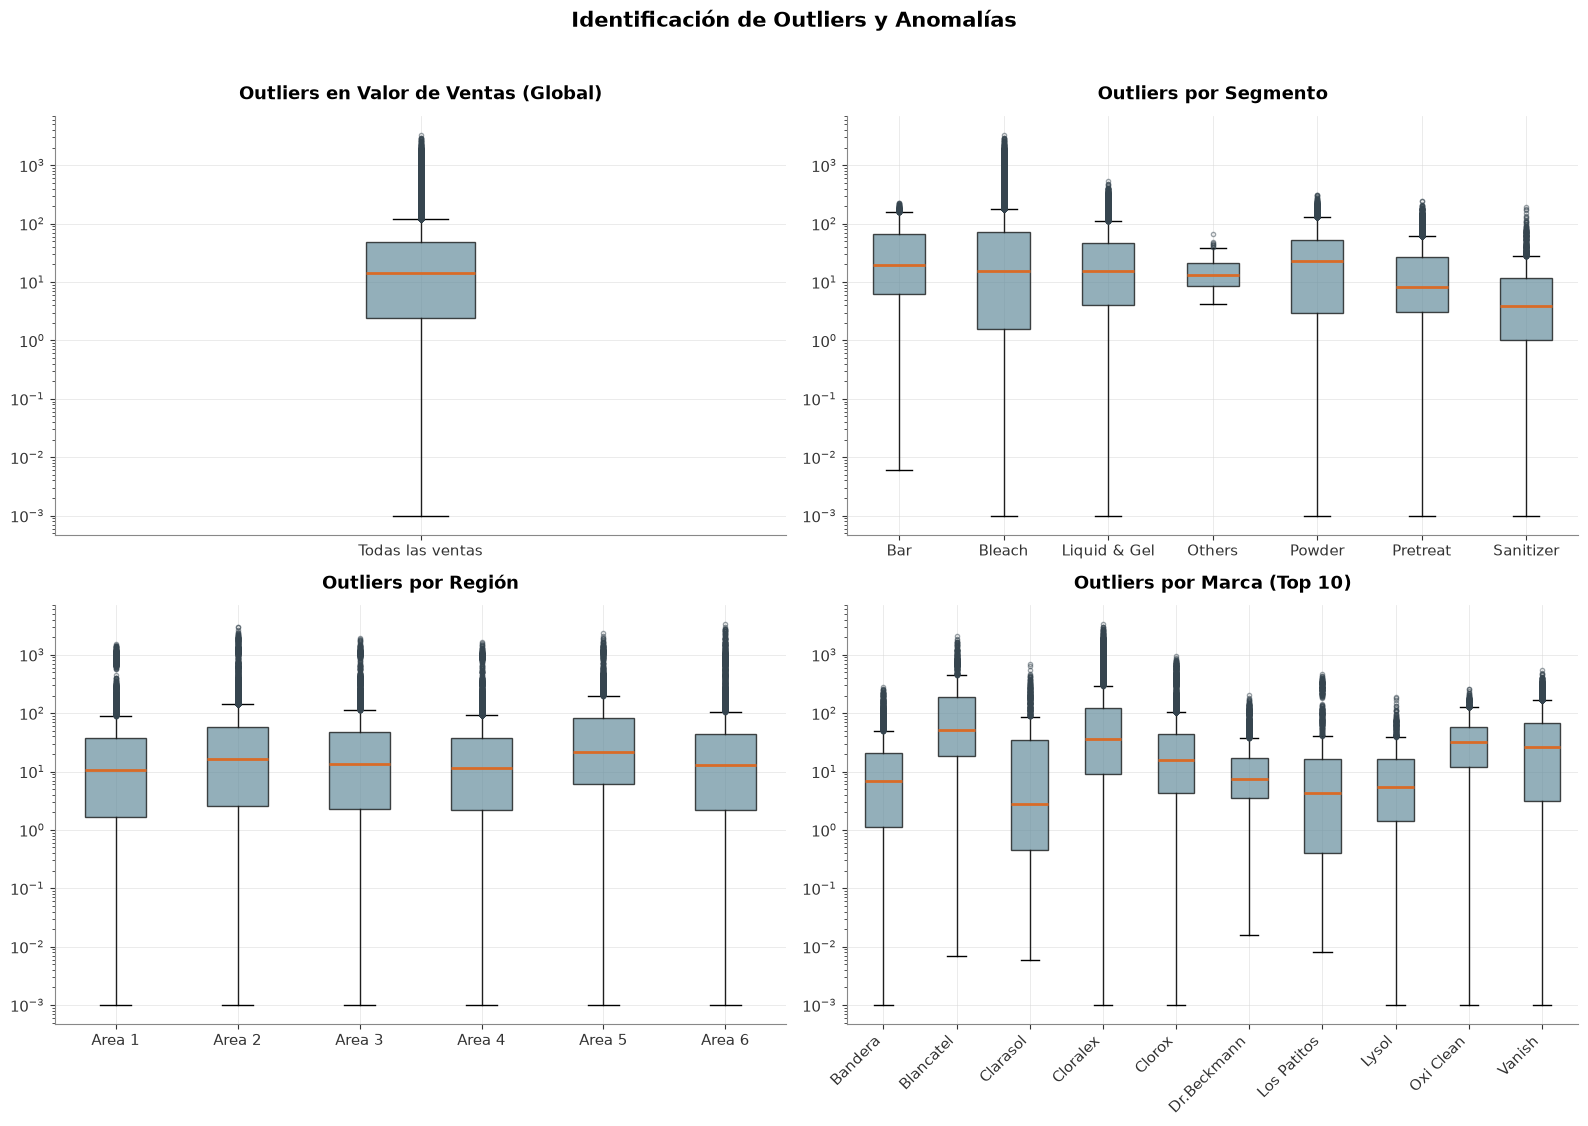

Límite superior IQR: $119.99
Outliers totales: 10,022 (9.92%)
Anomalías (< $0.01): 410

Top 10 transacciones más altas:
      date    brand segment region_short  total_value_sales  total_unit_sales
2023-06-05 Cloralex  Bleach       Area 6           3307.388            99.770
2023-06-05 Cloralex  Bleach       Area 2           2983.001           135.953
2023-07-03 Cloralex  Bleach       Area 6           2947.336            81.913
2022-06-05 Cloralex  Bleach       Area 2           2945.019           134.124
2023-01-09 Cloralex  Bleach       Area 6           2813.144            85.148
2023-03-06 Cloralex  Bleach       Area 6           2789.218            73.803
2023-05-08 Cloralex  Bleach       Area 6           2767.812            76.559
2023-07-10 Cloralex  Bleach       Area 6           2710.868            74.897
2023-05-22 Cloralex  Bleach       Area 6           2661.864            77.791
2023-05-01 Cloralex  Bleach       Area 6           2657.641            72.539


In [147]:
Q1, Q3 = df['total_value_sales'].quantile([0.25, 0.75])
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

outliers = df[(df['total_value_sales'] > limite_superior) | (df['total_value_sales'] < limite_inferior)]
anomalias_bajo = df[df['total_value_sales'] < 0.01]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
box_kwargs = dict(patch_artist=True, medianprops=dict(color=PALETTE['accent'], linewidth=2),
                   flierprops=dict(markeredgecolor=PALETTE['primary'], markersize=3, alpha=0.5))
box_color=PALETTE['fourth']

# BOXPLOT 1: Outliers en Valor de Ventas (Global)
df.boxplot(column='total_value_sales', ax=axes[0, 0], boxprops=dict(facecolor=box_color, alpha=0.7), **box_kwargs)
axes[0, 0].set_yscale('log'); plt.sca(axes[0, 0]); plt.title('')
axes[0, 0].set_title('Outliers en Valor de Ventas (Global)')
axes[0, 0].set_xticklabels(['Todas las ventas'])
axes[0, 0].set_xlabel('')

# BOXPLOT 2: Outliers por Segmento
df.boxplot(column='total_value_sales', by='segment', ax=axes[0, 1], boxprops=dict(facecolor=box_color, alpha=0.7), **box_kwargs)
axes[0, 1].set_yscale('log'); plt.sca(axes[0, 1]); plt.title('')
axes[0, 1].set_title('Outliers por Segmento')
axes[0, 1].set_xlabel('')

# BOXPLOT 3: Outliers por Región
df.boxplot(column='total_value_sales', by='region_short', ax=axes[1, 0], boxprops=dict(facecolor=box_color, alpha=0.7), **box_kwargs)
axes[1, 0].set_yscale('log'); plt.sca(axes[1, 0]); plt.title('')
axes[1, 0].set_title('Outliers por Región')
axes[1, 0].set_xlabel('')

# BOXPLOT 4: Outliers por Marca (Top 10)
top10_marcas = df.groupby('brand')['total_value_sales'].sum().nlargest(10).index
df[df['brand'].isin(top10_marcas)].boxplot(column='total_value_sales', by='brand', ax=axes[1, 1], boxprops=dict(facecolor=box_color, alpha=0.7), **box_kwargs)
axes[1, 1].set_yscale('log'); plt.sca(axes[1, 1]); plt.title('')
axes[1, 1].set_title('Outliers por Marca (Top 10)')
axes[1, 1].set_xlabel('')
plt.xticks(rotation=45, ha='right')

fig.suptitle('Identificación de Outliers y Anomalías', y=1.02)
plt.tight_layout()
plt.savefig('10_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Límite superior IQR: ${limite_superior:.2f}")
print(f"Outliers totales: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Anomalías (< $0.01): {len(anomalias_bajo):,}")

top10 = df.nlargest(10, 'total_value_sales')[['date', 'brand', 'segment', 'region_short', 'total_value_sales', 'total_unit_sales']]
print("\nTop 10 transacciones más altas:")
print(top10.to_string(index=False))

### Hallazgos:

- **9.92% de las transacciones (10,022 de 101,012)** son outliers estadísticos: cualquier venta por encima de \$119.99 se considera atípica según el método IQR, aunque muchas sean legítimas (compras mayoristas o de puntos de venta grandes).
- **410 registros** tienen ventas menores a \$0.01: probables errores de captura, muestras gratuitas registradas como venta, o devoluciones parciales mal etiquetadas; vale la pena investigarlos con el equipo de datos de origen.
- El porcentaje de outliers es similar entre las seis áreas (7.8%–10.2%): ninguna región concentra desproporcionadamente los valores extremos.
- Las diez transacciones más altas del dataset son, en su totalidad, ventas de **Cloralex** en distintas áreas, con montos entre \$2,657 y \$3,307: consistentes con compras mayoristas o de puntos de venta grandes, sin alcanzar valores desproporcionados.

**Interpretación:** los outliers se distribuyen de forma consistente con el resto del análisis, sin concentrarse desproporcionadamente en ninguna región: Bleach/Cloralex es el segmento y marca con más valores extremos, coherente con ser también el líder en ventas totales.

## 8. Insights consolidados

Resumen ejecutivo con las métricas clave de cada sección y recomendaciones estratégicas derivadas
del análisis.

In [148]:
ventas_marca_full = df.groupby('brand', observed=True)['total_value_sales'].sum().sort_values(ascending=False)
ventas_mensuales_completos = ventas_mensuales['total_value_sales'][ventas_mensuales.index != '2023-07']

cantidad_outliers = len(outliers)
porcentaje_outliers = cantidad_outliers / len(df) * 100

insights = f"""
1. VENTAS GENERALES (base: {len(df):,} transacciones de área regional)
   - Ventas totales: ${df['total_value_sales'].sum():,.2f}
   - Promedio por transacción: ${df['total_value_sales'].mean():.2f} | Mediana: ${df['total_value_sales'].median():.2f}
   - La brecha media/mediana confirma un modelo de alto volumen y ticket bajo con cola de valores altos

2. CONCENTRACIÓN DE SEGMENTO Y MARCA (riesgo de dependencia)
   - Segmento líder: {ventas_segmento.index[0]} con ${ventas_segmento['sum'].iloc[0]:,.2f} ({ventas_segmento['percentage'].iloc[0]:.1f}%)
   - Marca líder: {ventas_marca_full.index[0]} con ${ventas_marca_full.iloc[0]:,.2f} ({ventas_marca_full.iloc[0]/df['total_value_sales'].sum()*100:.1f}%)
   - Ambos superan individualmente la regla de Pareto (80/20): alta dependencia de un solo segmento y marca

3. TENDENCIA TEMPORAL
   - Mes pico: {ventas_mensuales['total_value_sales'].idxmax()} (${ventas_mensuales['total_value_sales'].max():,.2f})
   - Mes valle (excl. 2023-07 incompleto): {ventas_mensuales_completos.idxmin()} (${ventas_mensuales_completos.min():,.2f})
   - Estacionalidad clara: repunte en mayo, debilidad en febrero

4. DISTRIBUCIÓN GEOGRÁFICA
   - Región líder: {ventas_region.index[0]} con {ventas_region['pct_ventas'].iloc[0]:.1f}% de las ventas regionales
   - El desempeño entre las 6 áreas es razonablemente parejo (rango de ticket promedio 1.8x, no 6-7x)

5. OUTLIERS Y ANOMALÍAS
   - {cantidad_outliers:,} transacciones atípicas ({porcentaje_outliers:.2f}%), consistentes con el segmento/marca líder
   - {len(anomalias_bajo)} registros con venta < $0.01 a investigar como posibles errores de captura

6. CORRELACIONES CLAVE
   - Ventas y unidades correlacionan fuertemente (r=0.91): el crecimiento es impulsado por volumen, no por precio
   - Precio no correlaciona con ventas totales: productos caros y baratos generan niveles de venta similares en conjunto

7. RECOMENDACIONES ESTRATÉGICAS
   - DIVERSIFICACIÓN: impulsar Liquid & Gel y Powder para reducir la dependencia de Bleach/Cloralex
   - DATOS: investigar los {len(anomalias_bajo)} registros de venta casi nula antes de usarlos en reportes financieros
   - PROYECCIONES: excluir julio 2023 (mes incompleto) de cualquier comparación o pronóstico interanual
   - REGIONAL: usar Área 2 y Área 5 (mejor ticket promedio y volumen) como referencia de mejores prácticas para las áreas de menor desempeño
"""

print(insights)
with open('insights_eda_final.txt', 'w', encoding='utf-8') as f:
    f.write(insights)


1. VENTAS GENERALES (base: 101,012 transacciones de área regional)
   - Ventas totales: $5,521,430.57
   - Promedio por transacción: $54.66 | Mediana: $14.06
   - La brecha media/mediana confirma un modelo de alto volumen y ticket bajo con cola de valores altos

2. CONCENTRACIÓN DE SEGMENTO Y MARCA (riesgo de dependencia)
   - Segmento líder: Bleach con $3,790,642.19 (68.7%)
   - Marca líder: Cloralex con $2,696,809.34 (48.8%)
   - Ambos superan individualmente la regla de Pareto (80/20): alta dependencia de un solo segmento y marca

3. TENDENCIA TEMPORAL
   - Mes pico: 2023-01 ($357,314.26)
   - Mes valle (excl. 2023-07 incompleto): 2022-02 ($247,267.67)
   - Estacionalidad clara: repunte en mayo, debilidad en febrero

4. DISTRIBUCIÓN GEOGRÁFICA
   - Región líder: Area 2 con 21.5% de las ventas regionales
   - El desempeño entre las 6 áreas es razonablemente parejo (rango de ticket promedio 1.8x, no 6-7x)

5. OUTLIERS Y ANOMALÍAS
   - 10,022 transacciones atípicas (9.92%), consistent

# 9. Archivos generados

Todas las visualizaciones se guardaron como PNG (150 dpi) para su uso posterior en dashboards o
presentaciones, junto con el resumen ejecutivo de insights.

In [149]:
archivos_generados = [
    "00_paleta_diseno.png", "01_distribucion_ventas.png", "02_ventas_por_segmento.png", "03_ventas_por_marca.png",
    "04_tendencia_temporal.png", "05_ventas_trimestre.png", "06_tendencia_por_segmento.png", "07_matriz_correlacion.png", 
    "08_scatter_plots.png", "09_distribucion_geografica.png", "10_outliers.png", "insights_eda_final.txt",
]
for i, archivo in enumerate(archivos_generados, 1):
    print(f"{i:2}. {archivo}")
print(f"\nTotal: {len(archivos_generados)} archivos")

 1. 00_paleta_diseno.png
 2. 01_distribucion_ventas.png
 3. 02_ventas_por_segmento.png
 4. 03_ventas_por_marca.png
 5. 04_tendencia_temporal.png
 6. 05_ventas_trimestre.png
 7. 06_tendencia_por_segmento.png
 8. 07_matriz_correlacion.png
 9. 08_scatter_plots.png
10. 09_distribucion_geografica.png
11. 10_outliers.png
12. insights_eda_final.txt

Total: 12 archivos


# Conclusiones

**La historia detrás de los datos**: este negocio opera bajo un modelo de alto volumen y ticket bajo, con una fuerte concentración en un solo segmento (Bleach) y una sola marca (Cloralex) que en conjunto explican la mayor parte del desempeño financiero. Esa concentración es, al mismo tiempo, la mayor fortaleza del negocio: una marca dominante y reconocida en el canal); y su mayor vulnerabilidad: cualquier caída en la demanda de ese segmento golpearía de forma desproporcionada los ingresos totales.

**Lo que aporta la vista regional**: al trabajar exclusivamente sobre las seis áreas regionales, excluyendo el total nacional, que es un agregado y no una observación de venta independiente, el desempeño geográfico resulta razonablemente parejo entre regiones, sin que ninguna domine de forma desproporcionada. Es una señal de un negocio con presencia distribuida, no dependiente de un solo mercado.

**Limitaciones a tener en cuenta antes de usar estos datos en reportes o pronósticos**: julio de 2023 está incompleto (datos solo hasta el día 17) y no debe compararse contra meses completos; los registros con venta casi nula requieren revisión antes de incorporarse a cifras financieras; y aunque cerca del 10% de las transacciones se marcan como outliers estadísticos, la mayoría corresponde a compras mayoristas legítimas, no a errores de captura.

**Próximos pasos**: esta caracterización del negocio (la concentración en Bleach/Cloralex, el patrón estacional, el vínculo entre volumen y venta más que precio, y el equilibrio entre regiones) sienta la base para el modelo de segmentación (K-Means) que se documenta como el siguiente proyecto del portafolio, donde se reutiliza el mismo sistema de diseño (`PALETTE`, `SEGMENT_COLORS`,`CMAP_DIVERGING`) para mantener continuidad visual.